Nota Média por Status de Entrega:
atraso
False    4.210877
True     2.655341
Name: review_score, dtype: float64

Frete Médio por Status de Entrega:
atraso
False    19.749209
True     21.323366
Name: freight_value, dtype: float64

Métricas por Faixa de Preço:
             review_score  tempo_entrega
faixa_preco                             
Barato           4.088185      10.402819
Médio            4.095744      11.298418
Caro             4.101830      11.791488
Premium          4.126055      12.518024


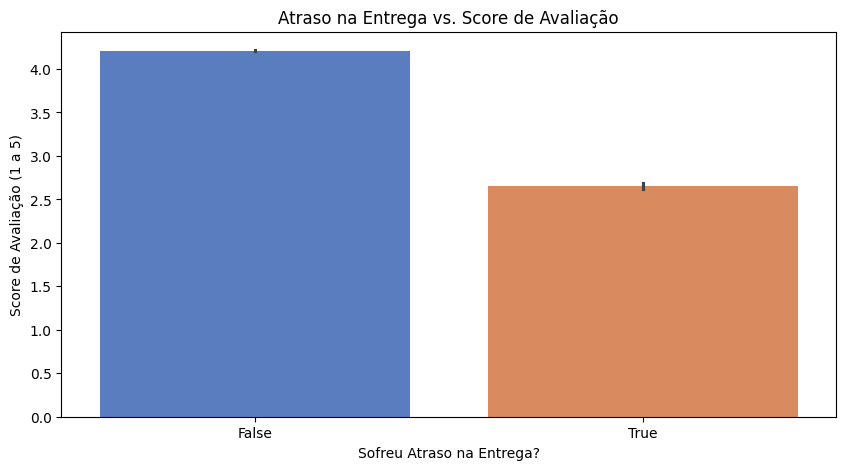

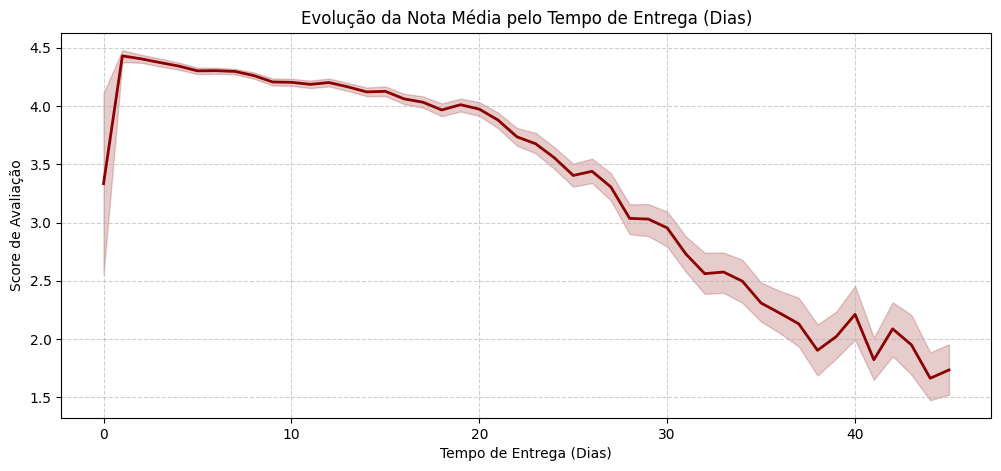

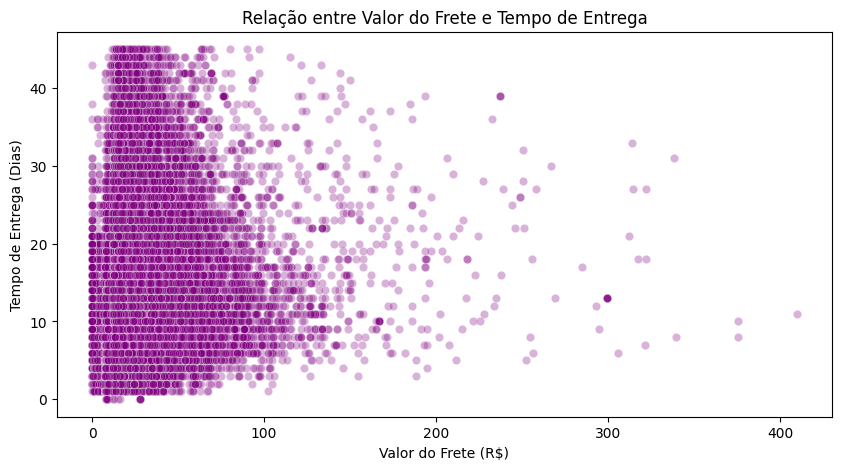

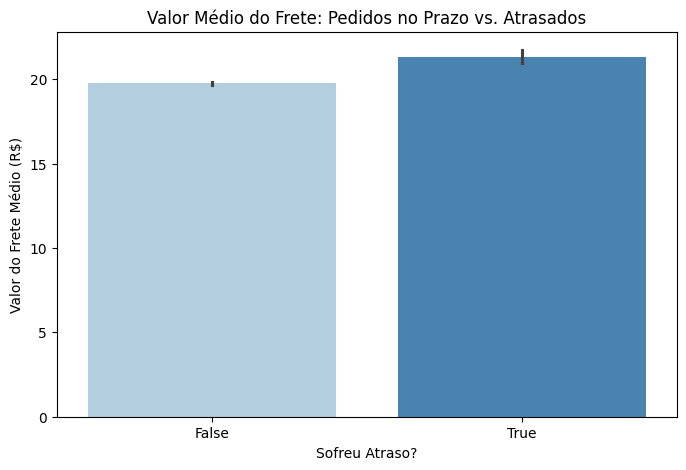

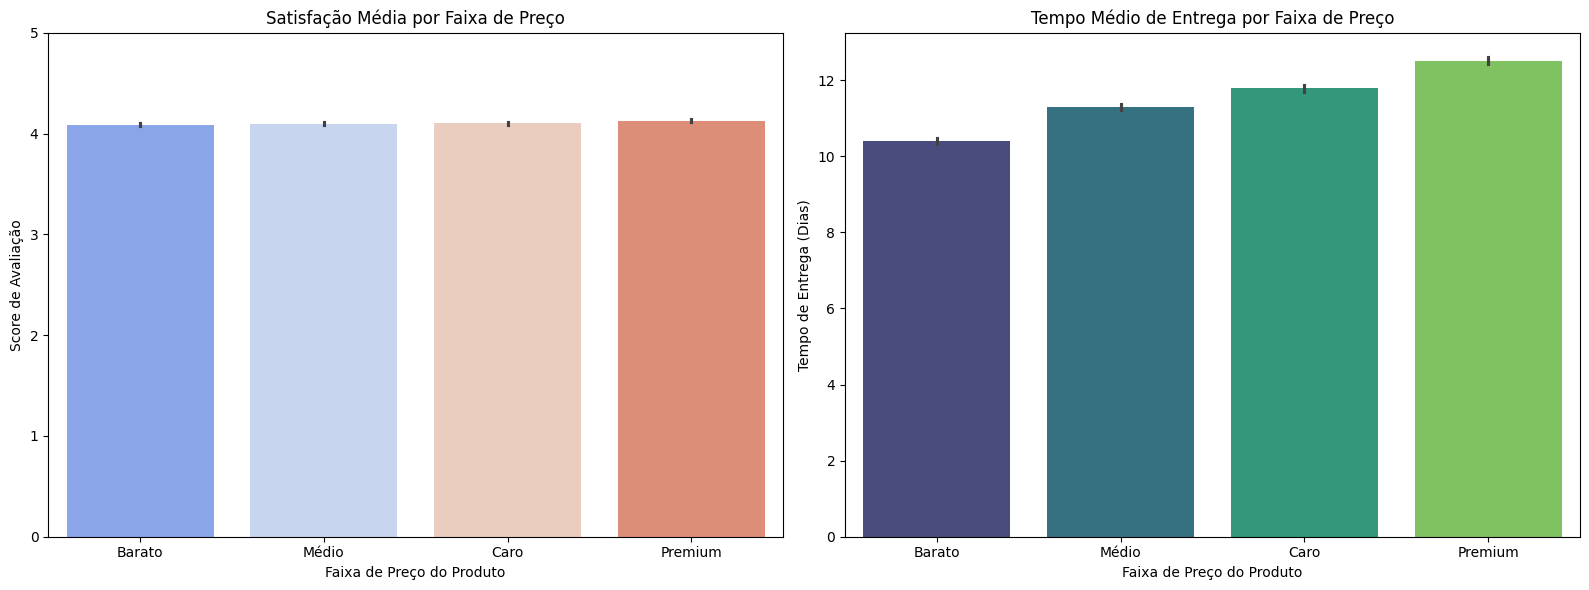

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos datasets
pedidos = pd.read_csv('/content/olist_orders_dataset.csv')
itens = pd.read_csv('/content/olist_order_items_dataset.csv')
produtos = pd.read_csv('/content/olist_products_dataset.csv')
avaliacoes = pd.read_csv('/content/olist_order_reviews_dataset.csv')

# Cruzamento das tabelas
pedidositens = pd.merge(pedidos, itens, on='order_id', how='inner')
pedidositensprodutos = pd.merge(pedidositens, produtos, on='product_id', how='left')
completo = pd.merge(pedidositensprodutos, avaliacoes, on='order_id', how='inner')

# Conversão de datas e cálculo de métricas logísticas
completo['order_purchase_timestamp'] = pd.to_datetime(completo['order_purchase_timestamp'])
completo['order_delivered_customer_date'] = pd.to_datetime(completo['order_delivered_customer_date'])
completo['order_estimated_delivery_date'] = pd.to_datetime(completo['order_estimated_delivery_date'])

completo['tempo_entrega'] = (completo['order_delivered_customer_date'] - completo['order_purchase_timestamp']).dt.days
completo['atraso'] = completo['order_delivered_customer_date'] > completo['order_estimated_delivery_date']

# Filtro de outliers (entregas em até 45 dias) e quebra por faixas de preço
df_filtrado = completo[completo['tempo_entrega'] <= 45].copy()
df_filtrado['faixa_preco'] = pd.qcut(df_filtrado['price'], q=4, labels=['Barato', 'Médio', 'Caro', 'Premium'])

# Exibição dos resultados numéricos no terminal
print("Nota Média por Status de Entrega:")
print(df_filtrado.groupby('atraso')['review_score'].mean())

print("\nFrete Médio por Status de Entrega:")
print(df_filtrado.groupby('atraso')['freight_value'].mean())

print("\nMétricas por Faixa de Preço:")
print(df_filtrado.groupby('faixa_preco', observed=False)[['review_score', 'tempo_entrega']].mean())


# --- GRÁFICOS ---

# 1. Impacto do atraso na nota do cliente
plt.figure(figsize=(10, 5))
sns.barplot(x='atraso', y='review_score', data=df_filtrado, hue='atraso', palette='muted', legend=False)
plt.title('Atraso na Entrega vs. Score de Avaliação')
plt.xlabel('Sofreu Atraso na Entrega?')
plt.ylabel('Score de Avaliação (1 a 5)')
plt.show()

# 2. Tendência da nota pelo tempo de entrega (dias)
plt.figure(figsize=(12, 5))
sns.lineplot(x='tempo_entrega', y='review_score', data=df_filtrado, color='darkred', linewidth=2)
plt.title("Evolução da Nota Média pelo Tempo de Entrega (Dias)")
plt.xlabel('Tempo de Entrega (Dias)')
plt.ylabel('Score de Avaliação')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Dispersão entre valor do frete e tempo de entrega
plt.figure(figsize=(10, 5))
sns.scatterplot(x="freight_value", y="tempo_entrega", data=df_filtrado, alpha=0.3, color='purple')
plt.title("Relação entre Valor do Frete e Tempo de Entrega")
plt.xlabel("Valor do Frete (R$)")
plt.ylabel("Tempo de Entrega (Dias)")
plt.show()

# 4. Frete médio pago nos casos de atraso
plt.figure(figsize=(8, 5))
sns.barplot(x='atraso', y='freight_value', data=df_filtrado, hue='atraso', palette='Blues', legend=False)
plt.title('Valor Médio do Frete: Pedidos no Prazo vs. Atrasados')
plt.xlabel('Sofreu Atraso?')
plt.ylabel('Valor do Frete Médio (R$)')
plt.show()

# 5 e 6. Comparativo por faixas de preço (Satisfação vs. Tempo de Entrega)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='faixa_preco', y='review_score', data=df_filtrado, hue='faixa_preco', palette='coolwarm', legend=False, ax=axes[0])
axes[0].set_title('Satisfação Média por Faixa de Preço')
axes[0].set_xlabel('Faixa de Preço do Produto')
axes[0].set_ylabel('Score de Avaliação')
axes[0].set_ylim(0, 5)

sns.barplot(x='faixa_preco', y='tempo_entrega', data=df_filtrado, hue='faixa_preco', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Tempo Médio de Entrega por Faixa de Preço')
axes[1].set_xlabel('Faixa de Preço do Produto')
axes[1].set_ylabel('Tempo de Entrega (Dias)')

plt.tight_layout()
plt.show()